<a href="https://colab.research.google.com/github/Karimzakyy/KarimZaky-55-1510/blob/main/Clustering_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clustering Project

**Deadline for submission: 17/3/2026 @ 11:59 PM**


Please make sure to explain your work using comments whenever possible.

**Objective:**
The objective of this project is to teach students how to apply clustering to real datasets.

You should be able to answer the following questions and provide reasonable justification for your answers:
* Which clustering approach have you decided to use on each dataset?
* Compare between Kmeans, Hierarchal and DBScan.
* Discuss how you tuned your clustering hyperparameters to achieve the best cluster assignment?
* What is the effect of different distance functions on the calculated clusters?
* How did you evaluate the performance of different clustering techniques on different datatsets?
* Visualize your output where applicable.
* What is the effect of scaling on the performance of clustering techniques?






Running this project requires the following imports:

In [ ]:
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import sklearn.preprocessing as prep
from sklearn.datasets import make_blobs
from plotnine import *
# StandardScaler is a function to normalize the data
# You may also check MinMaxScaler and MaxAbsScaler
#from sklearn.preprocessing import StandardScaler

from sklearn.cluster import DBSCAN


from sklearn.cluster import KMeans

from sklearn.metrics import silhouette_score

%matplotlib inline
# Please refer to the sklearn documentation to learn more about the different parameters for each clustering technique.

In [ ]:
# helper function that allows us to display data in 2 dimensions an highlights the clusters
def display_cluster(X,km=[],num_clusters=0):
    color = 'brgcmyk'  #List colors
    alpha = 0.5
    s = 20
    if num_clusters == 0:
        plt.scatter(X[:,0],X[:,1],c = color[0],alpha = alpha,s = s)
    else:
        for i in range(num_clusters):
            plt.scatter(X[km.labels_==i,0],X[km.labels_==i,1],c = color[i],alpha = alpha,s=s)
            plt.scatter(km.cluster_centers_[i][0],km.cluster_centers_[i][1],c = color[i], marker = 'x', s = 100)

## Multi Blob Data Set
* The dataset generated below is known to be best clustered into 6 clusters.
* Cluster the data set below using the three different clustering techniques discussed in the course.
* Visualize your clustering output in each step of your work.



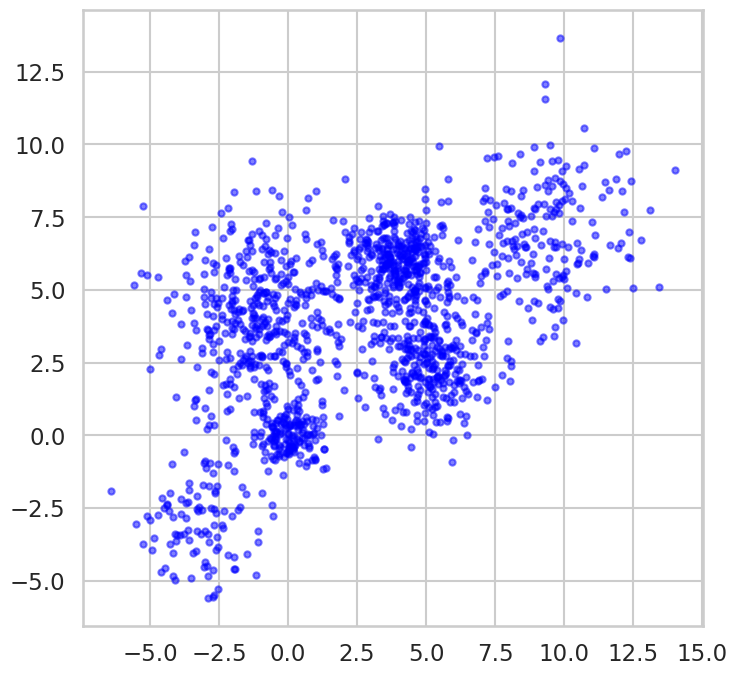

In [ ]:
#Data Generation and Visualization
plt.rcParams['figure.figsize'] = [8,8]
sns.set_style("whitegrid")
sns.set_context("talk")

n_bins = 6
centers = [(-3, -3), (0, 0), (5,2.5),(-1, 4), (4, 6), (9,7)]
Multi_blob_Data, y = make_blobs(n_samples=[100,150, 300, 400,300, 200], n_features=2, cluster_std=[1.3,0.6, 1.2, 1.7,0.9,1.7],
                  centers=centers, shuffle=False, random_state=42)
display_cluster(Multi_blob_Data)

### Kmeans
* Use Kmeans with different values of K to cluster the above data.
* Display the outcome of each value of K.
* Plot distortion function versus K and choose the approriate value of K.
* Plot the silhouette_score versus K and use it to choose the best K.
* Store the silhouette_score for the best K for later comparison with other clustering techniques.
* Comment on the effect of centroid initialization on cluster assignment.
* Hint: Lookup k-means++ .

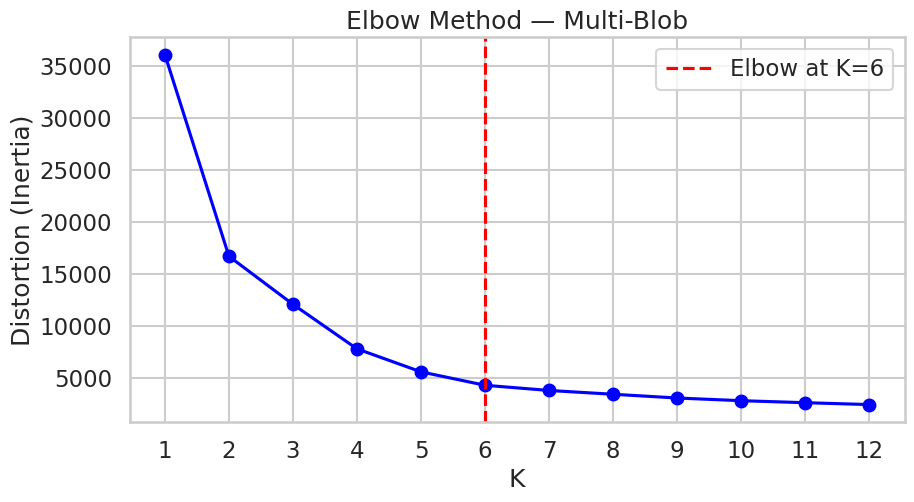

In [ ]:
# ── Elbow Method ─────────────────────────────────────────────────────────────
distortions = []
K_range = range(1, 13)

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(Multi_blob_Data)
    distortions.append(km.inertia_)

plt.figure(figsize=(10,5))
plt.plot(K_range, distortions, 'bo-')
plt.xlabel("K")
plt.ylabel("Distortion (Inertia)")
plt.title("Elbow Method — Multi-Blob")
plt.xticks(K_range)
plt.axvline(x=6, color='red', linestyle='--', label='Elbow at K=6')
plt.legend()
plt.show()

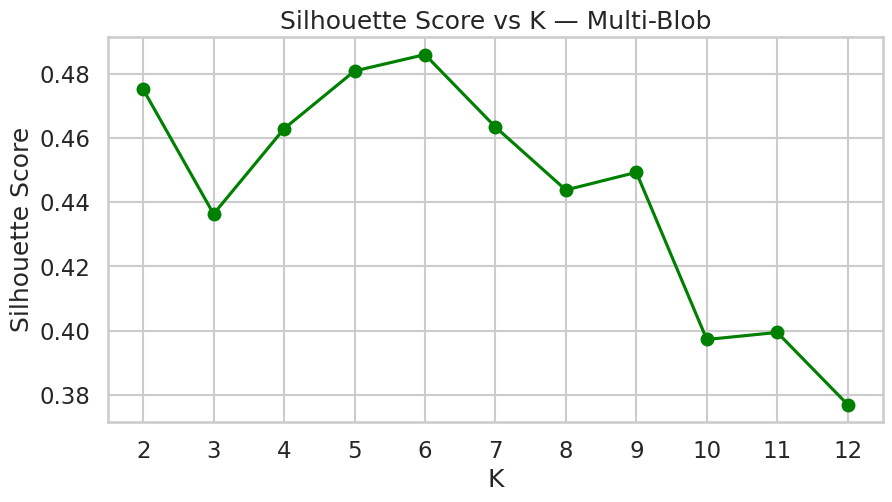

Best K: 6, Silhouette: 0.4860


In [ ]:
# ── Silhouette Score vs K ────────────────────────────────────────────────────
silhouette_scores = []
K_range2 = range(2, 13)

for k in K_range2:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(Multi_blob_Data)
    silhouette_scores.append(silhouette_score(Multi_blob_Data, km.labels_))

plt.figure(figsize=(10,5))
plt.plot(K_range2, silhouette_scores, 'go-')
plt.xlabel("K")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score vs K — Multi-Blob")
plt.xticks(K_range2)
plt.show()

best_k = K_range2[silhouette_scores.index(max(silhouette_scores))]
best_score_kmeans_blob = max(silhouette_scores)
print(f"Best K: {best_k}, Silhouette: {best_score_kmeans_blob:.4f}")

IndexError: string index out of range

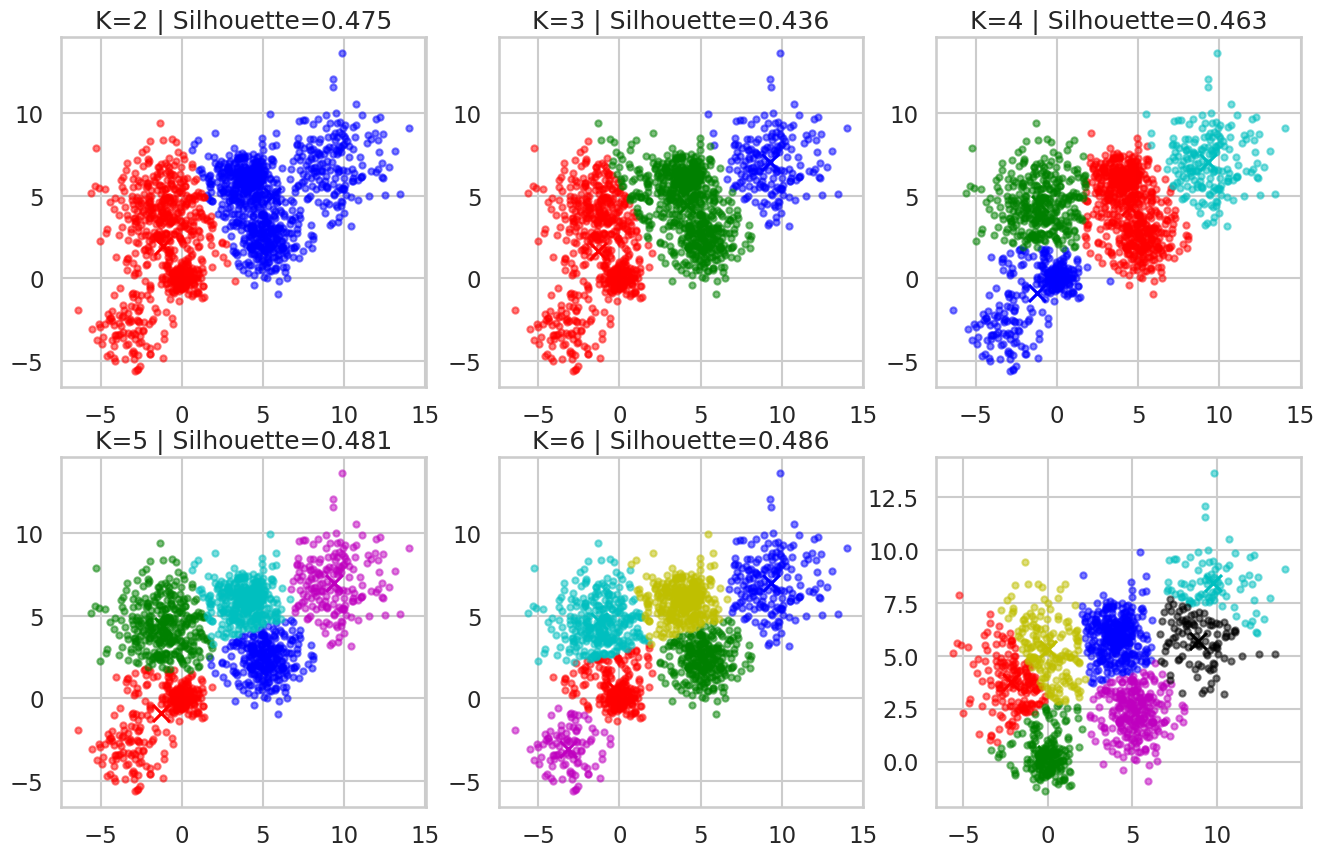

In [ ]:
# ── Visualize clusters for different K values ────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
for ax, k in zip(axes.flatten(), [2, 3, 4, 5, 6, 8]):
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(Multi_blob_Data)
    colors = 'brgcmyk'
    for i in range(k):
        ax.scatter(Multi_blob_Data[km.labels_==i,0], Multi_blob_Data[km.labels_==i,1],
                   c=colors[i], alpha=0.5, s=20)
        ax.scatter(km.cluster_centers_[i][0], km.cluster_centers_[i][1],
                   c=colors[i], marker='x', s=150)
    score = silhouette_score(Multi_blob_Data, km.labels_)
    ax.set_title(f"K={k} | Silhouette={score:.3f}")
plt.suptitle("K-Means with Different K Values")
plt.tight_layout()
plt.show()

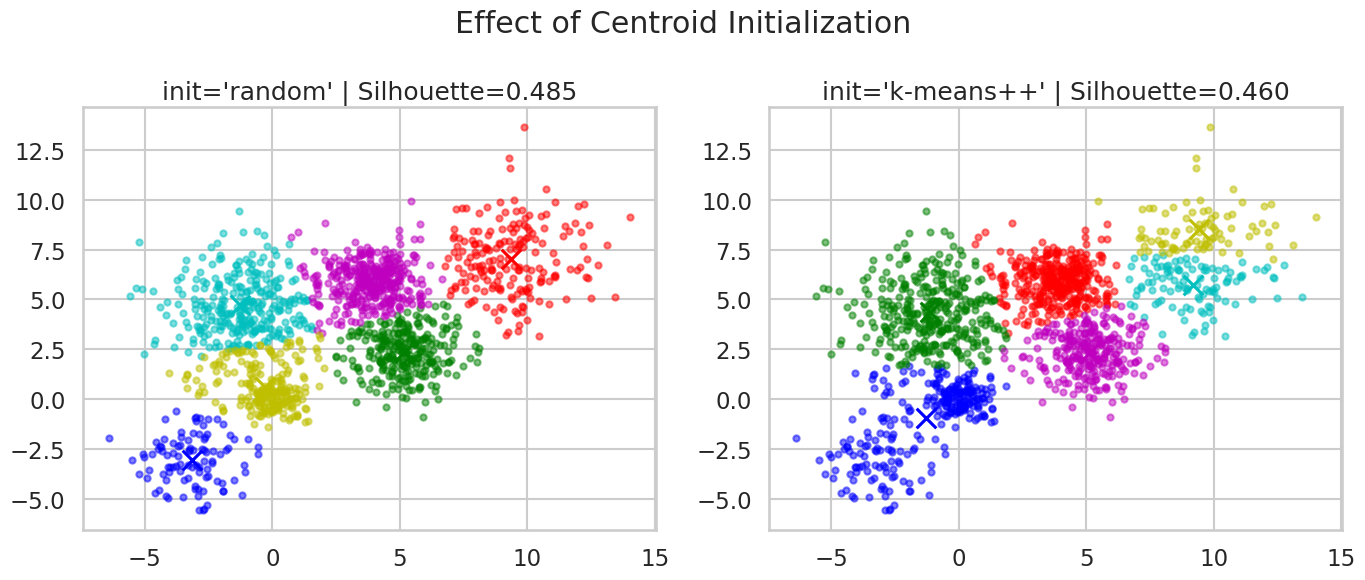

In [ ]:
# ── Effect of centroid initialization: random vs k-means++ ───────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, init_method in zip(axes, ['random', 'k-means++']):
    km = KMeans(n_clusters=6, init=init_method, n_init=1, random_state=0)
    km.fit(Multi_blob_Data)
    colors = 'brgcmy'
    for i in range(6):
        ax.scatter(Multi_blob_Data[km.labels_==i,0], Multi_blob_Data[km.labels_==i,1],
                   c=colors[i], alpha=0.5, s=20)
        ax.scatter(km.cluster_centers_[i][0], km.cluster_centers_[i][1],
                   c=colors[i], marker='x', s=200)
    score = silhouette_score(Multi_blob_Data, km.labels_)
    ax.set_title(f"init='{init_method}' | Silhouette={score:.3f}")
plt.suptitle("Effect of Centroid Initialization")
plt.tight_layout()
plt.show()

# k-means++ chooses initial centroids far apart → avoids bad local minima

### Hierarchal Clustering
* Use AgglomerativeClustering function to  to cluster the above data.
* In the  AgglomerativeClustering change the following parameters:
    * Affinity (use euclidean, manhattan and cosine)
    * Linkage(try different options)
    * Distance_threshold (try different options)
* Plot the dendrograph for one trial.
* For each of these trials, calculate the silhouette_score and display the resulting clusters.  
* Find the set of paramters that would find result in the best silhouette_score and store this score for later comparison with other clustering techniques.
* Record your observation.

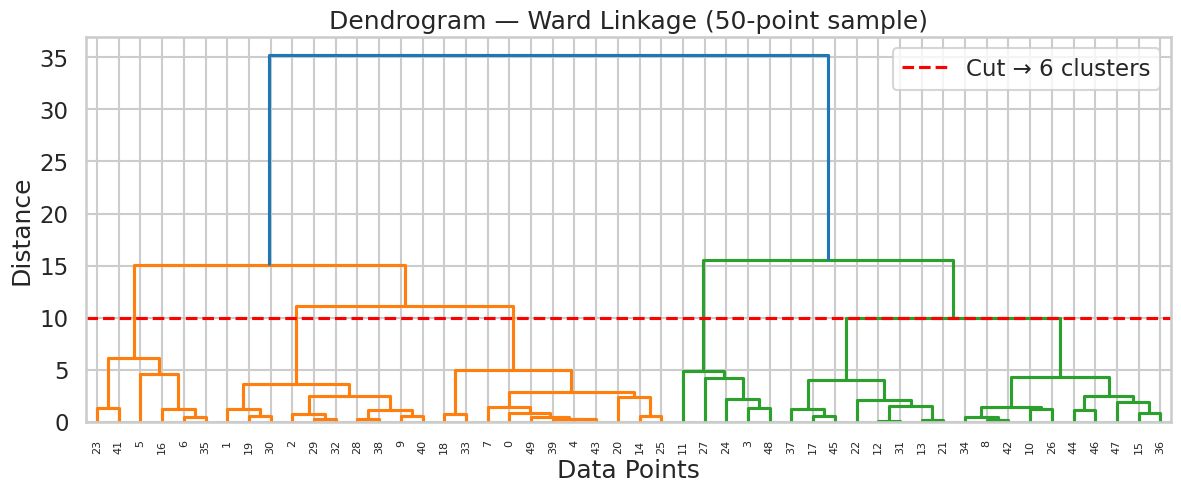

In [ ]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

# ── Dendrogram (sample of 50 points) ─────────────────────────────────────────
sample_idx = np.random.choice(len(Multi_blob_Data), 50, replace=False)
Z = linkage(Multi_blob_Data[sample_idx], method='ward', metric='euclidean')

plt.figure(figsize=(14, 5))
dendrogram(Z)
plt.title("Dendrogram — Ward Linkage (50-point sample)")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.axhline(y=10, color='red', linestyle='--', label='Cut → 6 clusters')
plt.legend()
plt.show()

In [ ]:
# ── Try different affinity + linkage combinations ────────────────────────────
configs = [
    ('euclidean', 'ward'),
    ('euclidean', 'complete'),
    ('euclidean', 'average'),
    ('manhattan', 'complete'),
    ('manhattan', 'average'),
    ('cosine',    'complete'),
    ('cosine',    'average'),
]

best_score_hier_blob = -1
best_labels_hier = None
best_config_hier = None

print(f"{'Affinity':<12} {'Linkage':<10} {'Silhouette'}")
print("-" * 36)

for affinity, lnk in configs:
    try:
        model = AgglomerativeClustering(n_clusters=6, metric=affinity, linkage=lnk)
        labels = model.fit_predict(Multi_blob_Data)
        score = silhouette_score(Multi_blob_Data, labels)
        print(f"{affinity:<12} {lnk:<10} {score:.4f}")
        if score > best_score_hier_blob:
            best_score_hier_blob = score
            best_labels_hier = labels
            best_config_hier = (affinity, lnk)
    except:
        print(f"{affinity:<12} {lnk:<10} N/A")

print(f"\nBest: {best_config_hier}, Silhouette: {best_score_hier_blob:.4f}")

Affinity     Linkage    Silhouette
------------------------------------
euclidean    ward       0.4687
euclidean    complete   0.3819
euclidean    average    0.4148
manhattan    complete   0.3370
manhattan    average    0.3803
cosine       complete   0.1885
cosine       average    0.2036

Best: ('euclidean', 'ward'), Silhouette: 0.4687


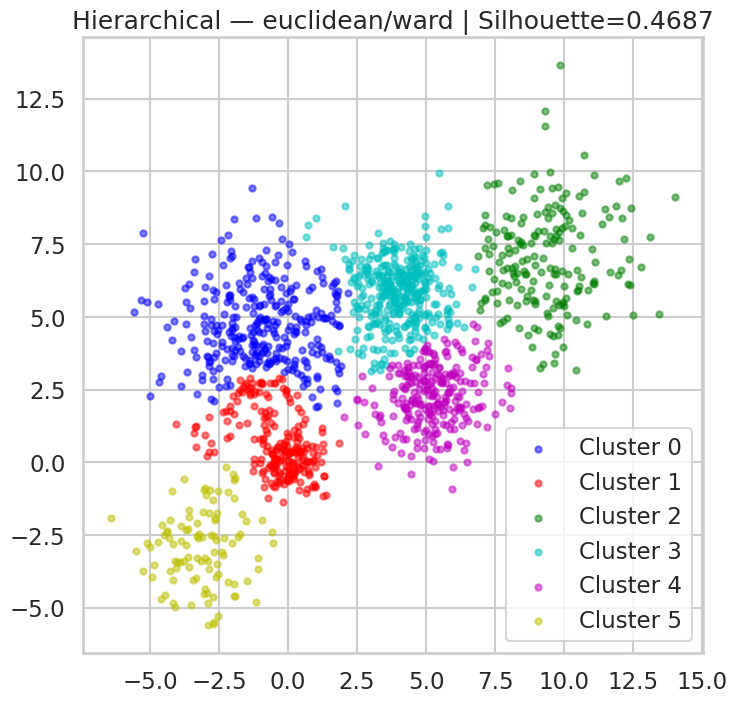

In [ ]:
# ── Visualize best Hierarchical result ───────────────────────────────────────
plt.figure(figsize=(8,8))
colors = 'brgcmy'
for i in range(6):
    plt.scatter(Multi_blob_Data[best_labels_hier==i,0],
                Multi_blob_Data[best_labels_hier==i,1],
                c=colors[i], alpha=0.5, s=20, label=f"Cluster {i}")
plt.title(f"Hierarchical — {best_config_hier[0]}/{best_config_hier[1]} | Silhouette={best_score_hier_blob:.4f}")
plt.legend()
plt.show()

### DBScan
* Use DBScan function to  to cluster the above data.
* In the  DBscan change the following parameters:
    * EPS (from 0.1 to 3)
    * Min_samples (from 5 to 25)

* Plot the silhouette_score versus the variation in the EPS and the min_samples.
* Plot the resulting Clusters in this case.
* Find the set of paramters that would find result in the best silhouette_score and store this score for later comparison with other clustering techniques.
* Record your observations and comments.

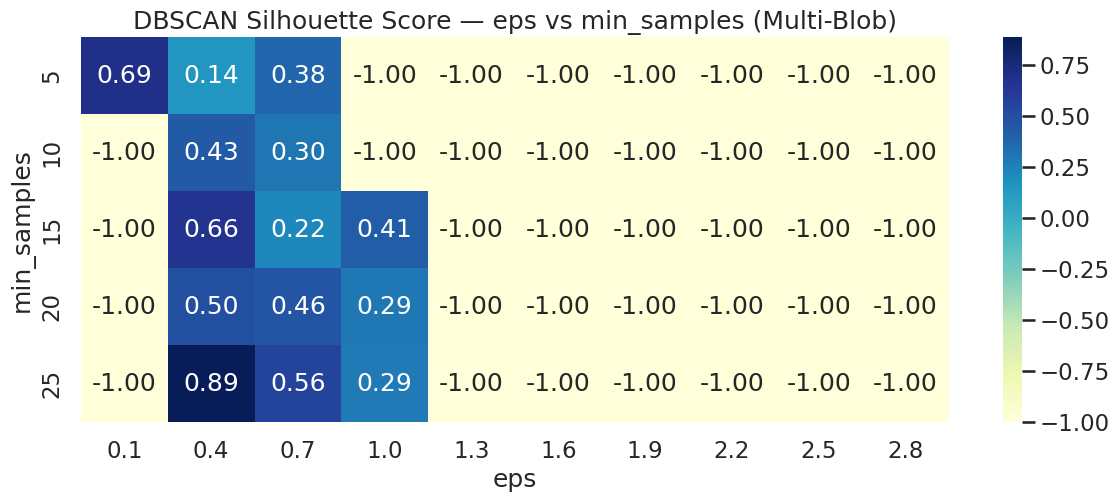

Best EPS=0.4, min_samples=25, Clusters=2, Silhouette=0.8881


In [ ]:
# ── Sweep EPS and min_samples ─────────────────────────────────────────────────
eps_values    = np.round(np.arange(0.1, 3.1, 0.3), 1)
min_s_values  = [5, 10, 15, 20, 25]
results = []

for eps in eps_values:
    for min_s in min_s_values:
        db = DBSCAN(eps=eps, min_samples=min_s)
        labels = db.fit_predict(Multi_blob_Data)
        n_cls = len(set(labels)) - (1 if -1 in labels else 0)
        if n_cls >= 2:
            score = silhouette_score(Multi_blob_Data[labels!=-1], labels[labels!=-1])
        else:
            score = -1
        results.append({'eps': eps, 'min_samples': min_s,
                        'n_clusters': n_cls, 'silhouette': score})

res_df = pd.DataFrame(results)

# ── Heatmap ───────────────────────────────────────────────────────────────────
pivot = res_df.pivot(index='min_samples', columns='eps', values='silhouette')
plt.figure(figsize=(14, 5))
sns.heatmap(pivot, annot=True, fmt=".2f", cmap='YlGnBu')
plt.title("DBSCAN Silhouette Score — eps vs min_samples (Multi-Blob)")
plt.show()

best_row = res_df.loc[res_df['silhouette'].idxmax()]
best_score_dbscan_blob = best_row['silhouette']
print(f"Best EPS={best_row['eps']}, min_samples={int(best_row['min_samples'])}, "
      f"Clusters={int(best_row['n_clusters'])}, Silhouette={best_score_dbscan_blob:.4f}")

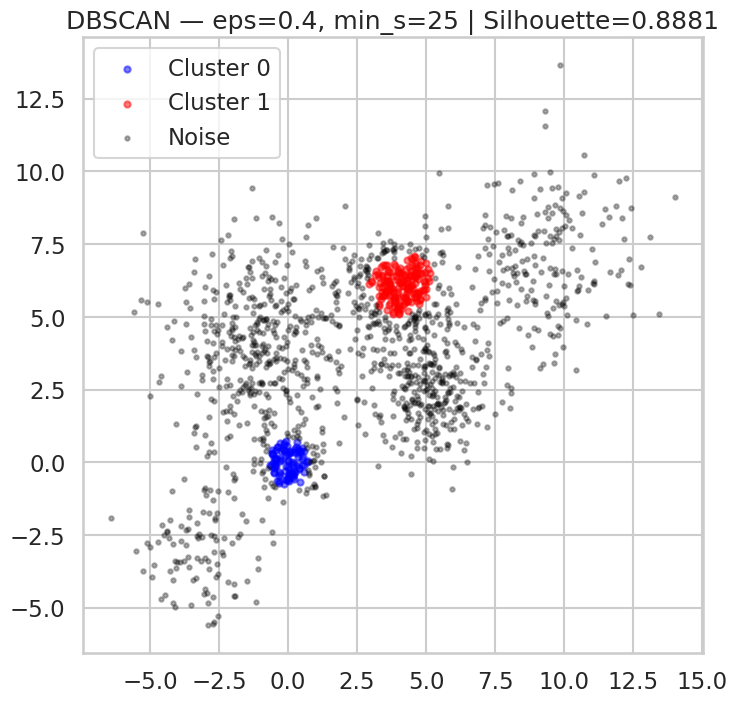

In [ ]:
# ── Visualize best DBSCAN result ──────────────────────────────────────────────
db_best = DBSCAN(eps=best_row['eps'], min_samples=int(best_row['min_samples']))
best_labels_db = db_best.fit_predict(Multi_blob_Data)

plt.figure(figsize=(8,8))
colors_all = ['b','r','g','c','m','y','orange','purple']
for label in set(best_labels_db):
    mask = best_labels_db == label
    if label == -1:
        plt.scatter(Multi_blob_Data[mask,0], Multi_blob_Data[mask,1],
                    c='black', s=10, alpha=0.3, label='Noise')
    else:
        plt.scatter(Multi_blob_Data[mask,0], Multi_blob_Data[mask,1],
                    c=colors_all[label % len(colors_all)], s=20, alpha=0.5,
                    label=f"Cluster {label}")
plt.title(f"DBSCAN — eps={best_row['eps']}, min_s={int(best_row['min_samples'])} | "
          f"Silhouette={best_score_dbscan_blob:.4f}")
plt.legend()
plt.show()

In [ ]:
# ── Compare all 3 on Multi-Blob ───────────────────────────────────────────────
print("=" * 45)
print("  COMPARISON — Multi-Blob Dataset")
print("=" * 45)
print(f"  K-Means       K=6:       {best_score_kmeans_blob:.4f}")
print(f"  Hierarchical  best:      {best_score_hier_blob:.4f}")
print(f"  DBSCAN        best:      {best_score_dbscan_blob:.4f}")
print("=" * 45)

  COMPARISON — Multi-Blob Dataset
  K-Means       K=6:       0.4860
  Hierarchical  best:      0.4687
  DBSCAN        best:      0.8881


## iris data set
The iris data set is test data set that is part of the Sklearn module
which contains 150 records each with 4 features. All the features are represented by real numbers.

The data represents three classes.


In [ ]:
from sklearn.datasets import load_iris
iris_data = load_iris()
iris_data.target[[10, 25, 50]]
#array([0, 0, 1])
list(iris_data.target_names)
['setosa', 'versicolor', 'virginica']


['setosa', 'versicolor', 'virginica']

* Repeat all the above clustering approaches and steps on the above data.
* Comment on the effect of scaling on clustering this dataset. Show the difference between clustering the data with and without   scaling.
* Compare between the different clustering approaches.
* Is your clustering outcome consistent with the labels?

K-Means Silhouette WITHOUT scaling: 0.5528
K-Means Silhouette WITH    scaling: 0.4599


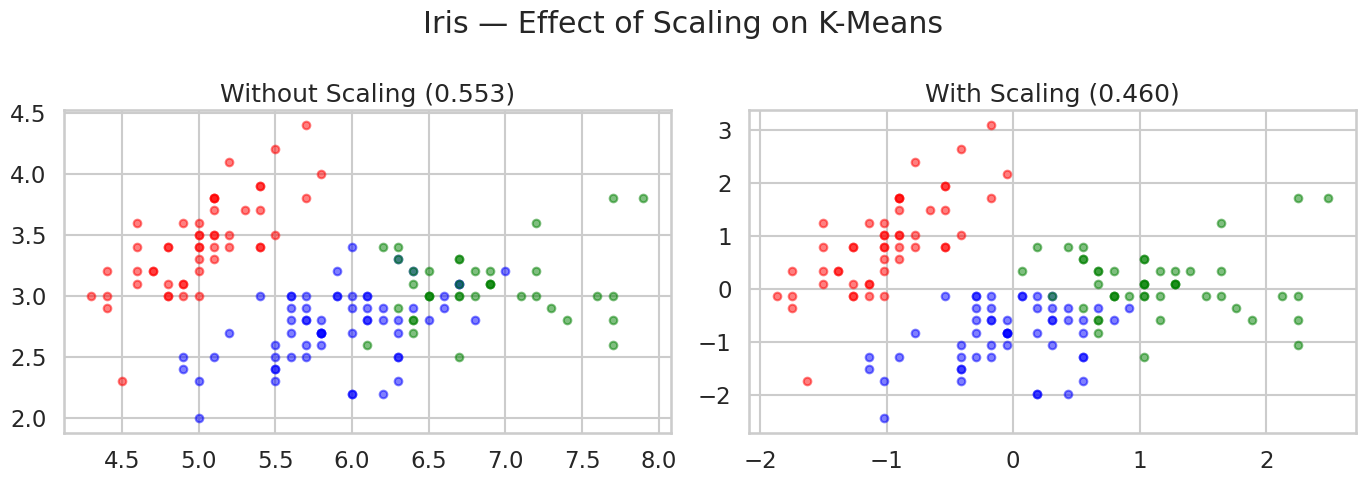

In [ ]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

iris = load_iris()
X_iris = iris.data
y_iris = iris.target

# ── Without scaling ──────────────────────────────────────────────────────────
km_no = KMeans(n_clusters=3, init='k-means++', n_init=10, random_state=42)
km_no.fit(X_iris)
score_no = silhouette_score(X_iris, km_no.labels_)

# ── With scaling ─────────────────────────────────────────────────────────────
scaler = StandardScaler()
X_iris_scaled = scaler.fit_transform(X_iris)
km_sc = KMeans(n_clusters=3, init='k-means++', n_init=10, random_state=42)
km_sc.fit(X_iris_scaled)
score_sc = silhouette_score(X_iris_scaled, km_sc.labels_)

print(f"K-Means Silhouette WITHOUT scaling: {score_no:.4f}")
print(f"K-Means Silhouette WITH    scaling: {score_sc:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14,5))
for ax, labels, title, X_plot in zip(
    axes,
    [km_no.labels_, km_sc.labels_],
    [f"Without Scaling ({score_no:.3f})", f"With Scaling ({score_sc:.3f})"],
    [X_iris, X_iris_scaled]
):
    for i, c in enumerate(['b','r','g']):
        ax.scatter(X_plot[labels==i,0], X_plot[labels==i,1], c=c, alpha=0.5, s=30)
    ax.set_title(title)
plt.suptitle("Iris — Effect of Scaling on K-Means")
plt.tight_layout()
plt.show()

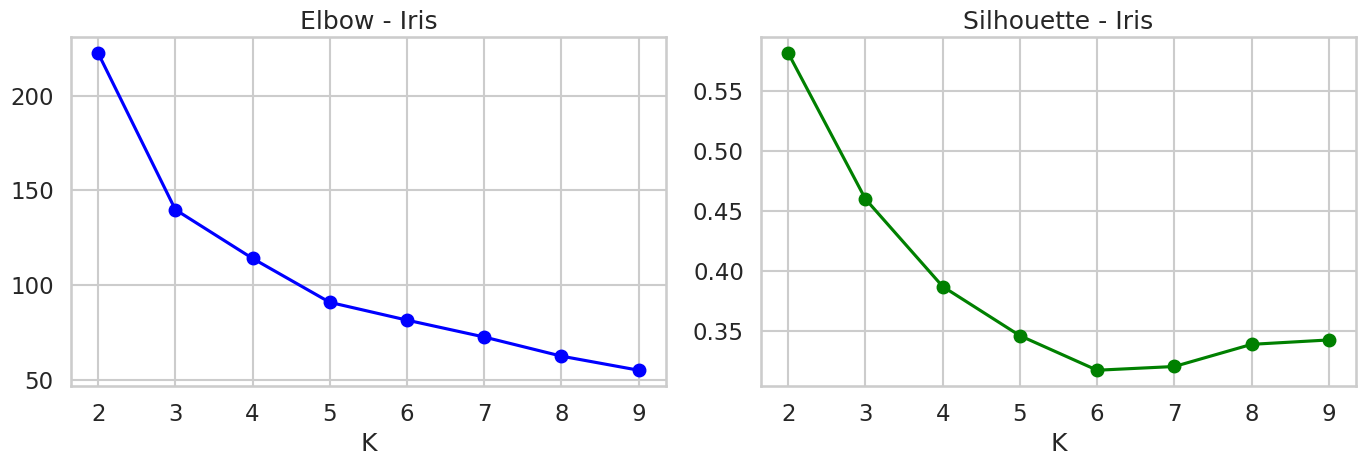

Best K=2, Silhouette=0.5818


In [ ]:
distortions_iris, sil_iris = [], []

for k in range(2, 10):
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_iris_scaled)
    distortions_iris.append(km.inertia_)
    sil_iris.append(silhouette_score(X_iris_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14,5))
axes[0].plot(range(2,10), distortions_iris, 'bo-')
axes[0].set_title("Elbow - Iris")
axes[0].set_xlabel("K")

axes[1].plot(range(2,10), sil_iris, 'go-')
axes[1].set_title("Silhouette - Iris")
axes[1].set_xlabel("K")

plt.tight_layout()
plt.show()

best_k_iris = list(range(2,10))[sil_iris.index(max(sil_iris))]
best_score_kmeans_iris = max(sil_iris)
print(f"Best K={best_k_iris}, Silhouette={best_score_kmeans_iris:.4f}")

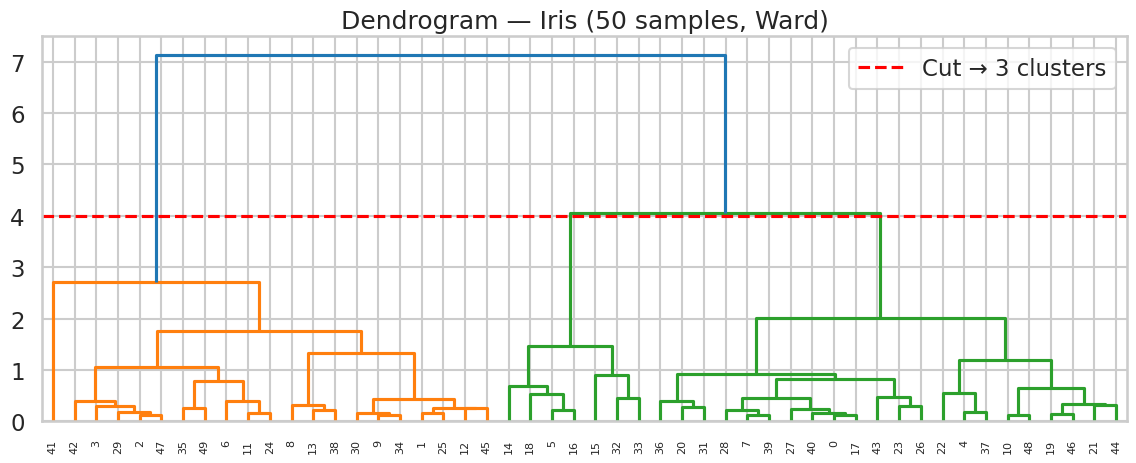

In [ ]:
# ── Dendrogram ────────────────────────────────────────────────────────────────
Z_iris = linkage(X_iris_scaled[:50], method='ward')
plt.figure(figsize=(14,5))
dendrogram(Z_iris)
plt.title("Dendrogram — Iris (50 samples, Ward)")
plt.axhline(y=4, color='red', linestyle='--', label='Cut → 3 clusters')
plt.legend()
plt.show()

In [ ]:
# ── Try different configs ─────────────────────────────────────────────────────
configs_iris = [
    ('euclidean','ward'), ('euclidean','complete'),
    ('euclidean','average'), ('manhattan','complete'), ('cosine','average')
]

best_score_hier_iris = -1
print(f"{'Affinity':<12} {'Linkage':<10} {'Silhouette'}")
print("-" * 36)

for affinity, lnk in configs_iris:
    try:
        model = AgglomerativeClustering(n_clusters=3, metric=affinity, linkage=lnk)
        labels = model.fit_predict(X_iris_scaled)
        score = silhouette_score(X_iris_scaled, labels)
        print(f"{affinity:<12} {lnk:<10} {score:.4f}")
        if score > best_score_hier_iris:
            best_score_hier_iris = score
    except:
        print(f"{affinity:<12} {lnk:<10} N/A")

print(f"\nBest Hierarchical Silhouette (Iris): {best_score_hier_iris:.4f}")

Affinity     Linkage    Silhouette
------------------------------------
euclidean    ward       0.4467
euclidean    complete   0.4496
euclidean    average    0.4803
manhattan    complete   0.4350
cosine       average    0.4302

Best Hierarchical Silhouette (Iris): 0.4803


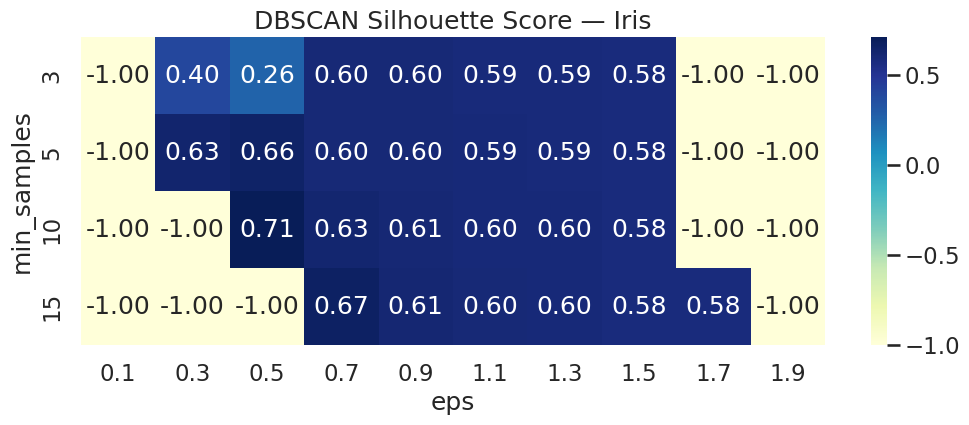

Best DBSCAN Iris: eps=0.5, min_s=10, Silhouette=0.7101


In [ ]:
eps_vals = np.round(np.arange(0.1, 2.0, 0.2), 1)
min_s_vals = [3, 5, 10, 15]
results_iris = []

for eps in eps_vals:
    for min_s in min_s_vals:
        db = DBSCAN(eps=eps, min_samples=min_s)
        labels = db.fit_predict(X_iris_scaled)
        n_cls = len(set(labels)) - (1 if -1 in labels else 0)
        score = silhouette_score(X_iris_scaled[labels!=-1], labels[labels!=-1]) if n_cls >= 2 else -1
        results_iris.append({'eps': eps, 'min_samples': min_s, 'silhouette': score})

res_iris = pd.DataFrame(results_iris)
pivot_iris = res_iris.pivot(index='min_samples', columns='eps', values='silhouette')

plt.figure(figsize=(12,4))
sns.heatmap(pivot_iris, annot=True, fmt=".2f", cmap='YlGnBu')
plt.title("DBSCAN Silhouette Score — Iris")
plt.show()

best_iris_db = res_iris.loc[res_iris['silhouette'].idxmax()]
best_score_dbscan_iris = best_iris_db['silhouette']
print(f"Best DBSCAN Iris: eps={best_iris_db['eps']}, "
      f"min_s={int(best_iris_db['min_samples'])}, Silhouette={best_score_dbscan_iris:.4f}")

In [ ]:
# ── Consistency with true labels ─────────────────────────────────────────────
from sklearn.metrics import adjusted_rand_score

km_iris_final = KMeans(n_clusters=3, init='k-means++', n_init=10, random_state=42)
km_iris_final.fit(X_iris_scaled)
ari = adjusted_rand_score(y_iris, km_iris_final.labels_)
print(f"Adjusted Rand Index (K-Means vs True Labels): {ari:.4f}")
# ARI close to 1 = clustering matches true species labels

print("=" * 45)
print("  COMPARISON — Iris Dataset")
print("=" * 45)
print(f"  K-Means (K=3):       {best_score_kmeans_iris:.4f}")
print(f"  Hierarchical best:   {best_score_hier_iris:.4f}")
print(f"  DBSCAN best:         {best_score_dbscan_iris:.4f}")
print("=" * 45)

Adjusted Rand Index (K-Means vs True Labels): 0.6201
  COMPARISON — Iris Dataset
  K-Means (K=3):       0.5818
  Hierarchical best:   0.4803
  DBSCAN best:         0.7101


## Customer dataset
Repeat all the above on the customer data set

In [26]:
from google.colab import drive
drive.mount('/content/drive')

df_cust = pd.read_csv('/content/drive/MyDrive/Customer data.csv')
df_cust = df_cust.drop('ID', axis=1)   # ID is not a feature

print(df_cust.shape)
df_cust.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(2000, 7)


,Sex,Marital status,Age,Education,Income,Occupation,Settlement size
0,0,0,67,2,124670,1,2
1,1,1,22,1,150773,1,2
2,0,0,49,1,89210,0,0
3,0,0,45,1,171565,1,1
4,0,0,53,1,149031,1,1


In [28]:
# ── Scale the data ────────────────────────────────────────────────────────────
scaler_cust = StandardScaler()
X_cust = scaler_cust.fit_transform(df_cust)
print("Scaling applied — Income and other features now on equal scale")

Scaling applied — Income and other features now on equal scale


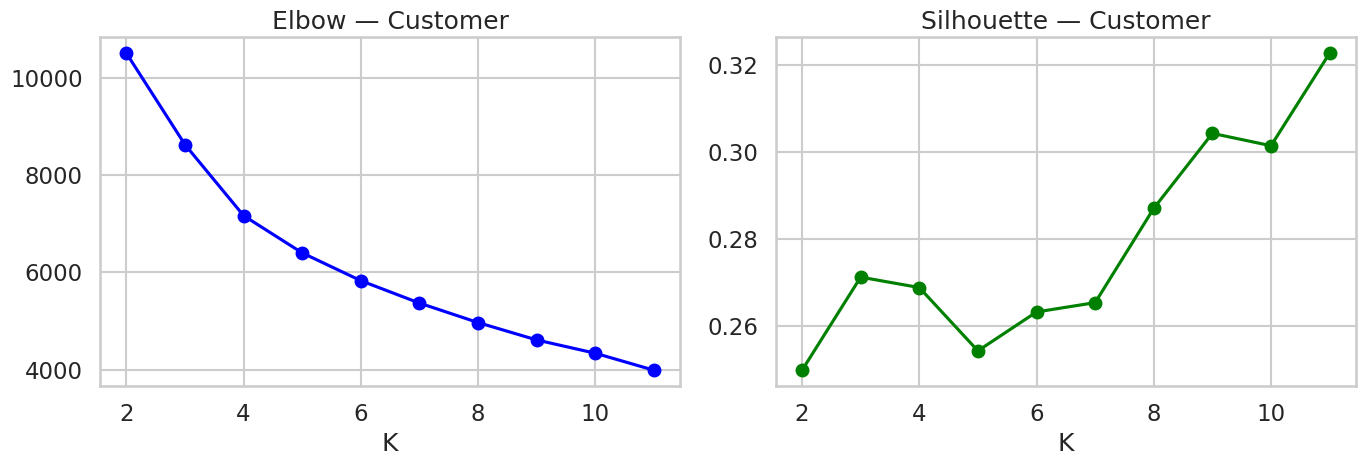

Best K=11, Silhouette=0.3227


In [29]:
# ── K-Means: Elbow + Silhouette ───────────────────────────────────────────────
dist_cust, sil_cust = [], []

for k in range(2, 12):
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_cust)
    dist_cust.append(km.inertia_)
    sil_cust.append(silhouette_score(X_cust, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14,5))
axes[0].plot(range(2,12), dist_cust, 'bo-')
axes[0].set_title("Elbow — Customer"); axes[0].set_xlabel("K")
axes[1].plot(range(2,12), sil_cust, 'go-')
axes[1].set_title("Silhouette — Customer"); axes[1].set_xlabel("K")
plt.tight_layout()
plt.show()

best_k_cust = range(2,12)[sil_cust.index(max(sil_cust))]
best_score_kmeans_cust = max(sil_cust)
print(f"Best K={best_k_cust}, Silhouette={best_score_kmeans_cust:.4f}")

IndexError: list index out of range

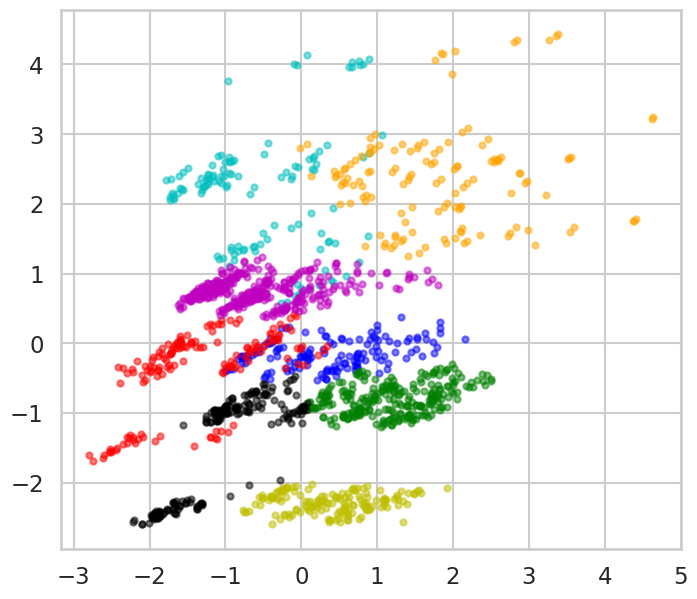

In [30]:
# ── Visualize using PCA (data has 7 features → reduce to 2D) ─────────────────
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
X_cust_2d = pca.fit_transform(X_cust)

km_cust_best = KMeans(n_clusters=best_k_cust, init='k-means++', n_init=10, random_state=42)
km_cust_best.fit(X_cust)

plt.figure(figsize=(8,7))
colors = ['b','r','g','c','m','y','k','orange']
for i in range(best_k_cust):
    mask = km_cust_best.labels_ == i
    plt.scatter(X_cust_2d[mask,0], X_cust_2d[mask,1],
                c=colors[i], alpha=0.5, s=20, label=f"Cluster {i}")
plt.title(f"Customer K-Means K={best_k_cust} — PCA 2D | Silhouette={best_score_kmeans_cust:.4f}")
plt.legend()
plt.show()

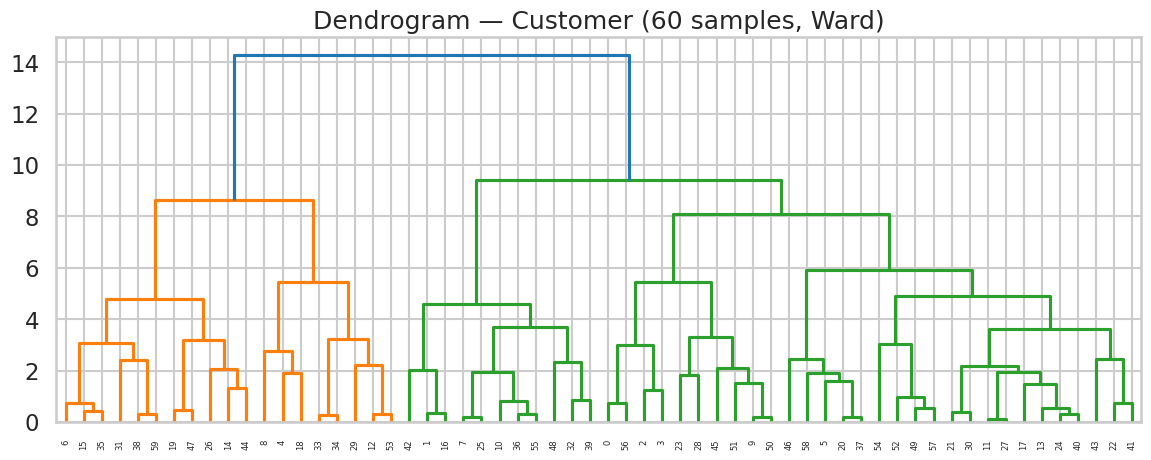

In [31]:
# ── Hierarchical Clustering ───────────────────────────────────────────────────
# Dendrogram
sample_cust = X_cust[np.random.choice(len(X_cust), 60, replace=False)]
Z_cust = linkage(sample_cust, method='ward')
plt.figure(figsize=(14,5))
dendrogram(Z_cust)
plt.title("Dendrogram — Customer (60 samples, Ward)")
plt.show()

In [32]:
configs_cust = [
    ('euclidean','ward'), ('euclidean','complete'),
    ('euclidean','average'), ('manhattan','complete')
]

best_score_hier_cust = -1
print(f"{'Affinity':<12} {'Linkage':<10} {'Silhouette'}")
print("-" * 36)

for affinity, lnk in configs_cust:
    try:
        model = AgglomerativeClustering(n_clusters=best_k_cust, metric=affinity, linkage=lnk)
        labels = model.fit_predict(X_cust)
        score = silhouette_score(X_cust, labels)
        print(f"{affinity:<12} {lnk:<10} {score:.4f}")
        if score > best_score_hier_cust:
            best_score_hier_cust = score
    except:
        print(f"{affinity:<12} {lnk:<10} N/A")

print(f"\nBest Hierarchical Silhouette (Customer): {best_score_hier_cust:.4f}")

Affinity     Linkage    Silhouette
------------------------------------
euclidean    ward       0.3073
euclidean    complete   0.1217
euclidean    average    0.2066
manhattan    complete   0.2412

Best Hierarchical Silhouette (Customer): 0.3073


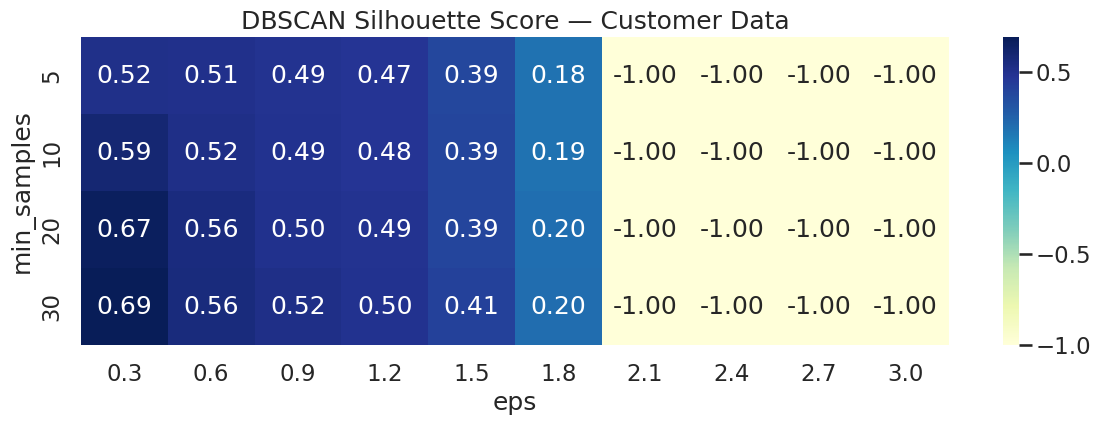

Best DBSCAN: eps=0.3, min_s=30, Silhouette=0.6905


In [33]:
# ── DBSCAN ────────────────────────────────────────────────────────────────────
eps_vals_c = np.round(np.arange(0.3, 3.0, 0.3), 1)
min_s_vals_c = [5, 10, 20, 30]
results_cust = []

for eps in eps_vals_c:
    for min_s in min_s_vals_c:
        db = DBSCAN(eps=eps, min_samples=min_s)
        labels = db.fit_predict(X_cust)
        n_cls = len(set(labels)) - (1 if -1 in labels else 0)
        score = silhouette_score(X_cust[labels!=-1], labels[labels!=-1]) if n_cls >= 2 else -1
        results_cust.append({'eps': eps, 'min_samples': min_s,
                              'n_clusters': n_cls, 'silhouette': score})

res_cust = pd.DataFrame(results_cust)
pivot_cust = res_cust.pivot(index='min_samples', columns='eps', values='silhouette')

plt.figure(figsize=(14,4))
sns.heatmap(pivot_cust, annot=True, fmt=".2f", cmap='YlGnBu')
plt.title("DBSCAN Silhouette Score — Customer Data")
plt.show()

best_cust_db = res_cust.loc[res_cust['silhouette'].idxmax()]
best_score_dbscan_cust = best_cust_db['silhouette']
print(f"Best DBSCAN: eps={best_cust_db['eps']}, min_s={int(best_cust_db['min_samples'])}, "
      f"Silhouette={best_score_dbscan_cust:.4f}")

In [34]:
# ── Final Comparison ──────────────────────────────────────────────────────────
print("=" * 45)
print("  COMPARISON — Customer Dataset")
print("=" * 45)
print(f"  K-Means (K={best_k_cust}):       {best_score_kmeans_cust:.4f}")
print(f"  Hierarchical best:   {best_score_hier_cust:.4f}")
print(f"  DBSCAN best:         {best_score_dbscan_cust:.4f}")
print("=" * 45)

# ── Cluster profiles ──────────────────────────────────────────────────────────
df_cust_labeled = df_cust.copy()
df_cust_labeled['Cluster'] = km_cust_best.labels_
print("\nCluster Profiles (Mean per cluster):")
print(df_cust_labeled.groupby('Cluster').mean().round(2))

  COMPARISON — Customer Dataset
  K-Means (K=11):       0.3227
  Hierarchical best:   0.3073
  DBSCAN best:         0.6905

Cluster Profiles (Mean per cluster):
          Sex  Marital status    Age  Education     Income  Occupation  \
Cluster                                                                  
0        0.00            1.00  28.93       1.00  122540.12        1.11   
1        1.00            0.00  33.31       0.80   95567.88        0.38   
2        0.00            0.00  42.33       1.00  131717.72        0.97   
3        0.77            0.75  53.01       2.12  108981.99        0.20   
4        1.00            1.00  27.68       1.00  119936.24        1.05   
5        0.00            0.00  27.63       0.00  123238.60        1.01   
6        0.00            0.00  35.05       0.66   89850.43        0.09   
7        0.65            1.00  50.51       2.15  167211.79        1.35   
8        0.00            0.00  63.78       2.00  170661.87        1.29   
9        0.82            